In [30]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("Instagram visits clustering.csv")

In [32]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [33]:
df.shape

(2600, 3)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


In [35]:
df.isna().sum()

User ID                    0
Instagram visit score      0
Spending_rank(0 to 100)    0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.describe()

,User ID,Instagram visit score,Spending_rank(0 to 100)
count,2600.000000,2600.000000,2600.000000
mean,1299.500000,63.323462,42.848408
std,750.699674,26.579760,28.758349
min,0.000000,5.000000,0.940709
25%,649.750000,38.000000,19.452098
50%,1299.500000,72.000000,28.013082
75%,1949.250000,86.000000,72.116945
max,2599.000000,118.000000,107.349821


In [38]:
df = df.drop('User ID',axis = 1)

In [39]:
df.head()

,Instagram visit score,Spending_rank(0 to 100)
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


In [40]:
df.columns

Index(['Instagram visit score', 'Spending_rank(0 to 100)'], dtype='object')

In [41]:
X = df[['Instagram visit score', 'Spending_rank(0 to 100)']]

In [42]:
X.head()

,Instagram visit score,Spending_rank(0 to 100)
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [44]:
X_scaled[:5]

array([[-0.01217181, -0.65376894],
       [-0.08743151, -0.61298749],
       [ 1.53065202, -0.84583579],
       [ 0.70279533,  1.53173941],
       [-1.85603443, -0.39495297]])

In [45]:
from sklearn.cluster import KMeans

In [46]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

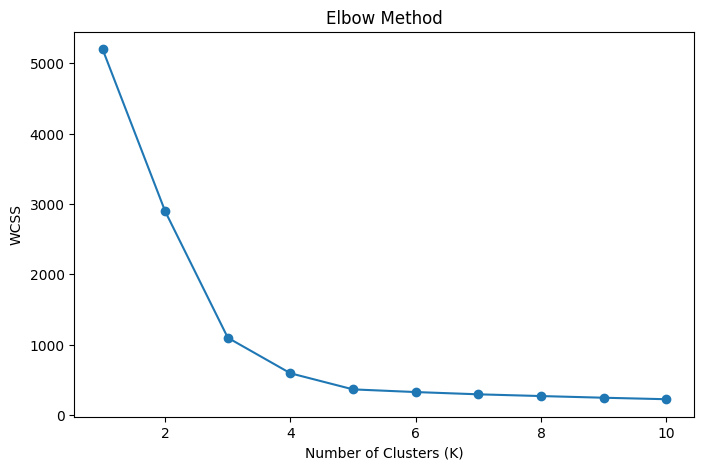

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [48]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X_scaled)

In [49]:
y_kmeans[:10]

array([0, 0, 0, 2, 3, 2, 2, 2, 1, 0], dtype=int32)

In [50]:
df['Cluster'] = y_kmeans

In [51]:
df.head()

,Instagram visit score,Spending_rank(0 to 100),Cluster
0,63,24.050708,0
1,61,25.223290,0
2,104,18.528245,0
3,82,86.890232,2
4,14,31.492397,3


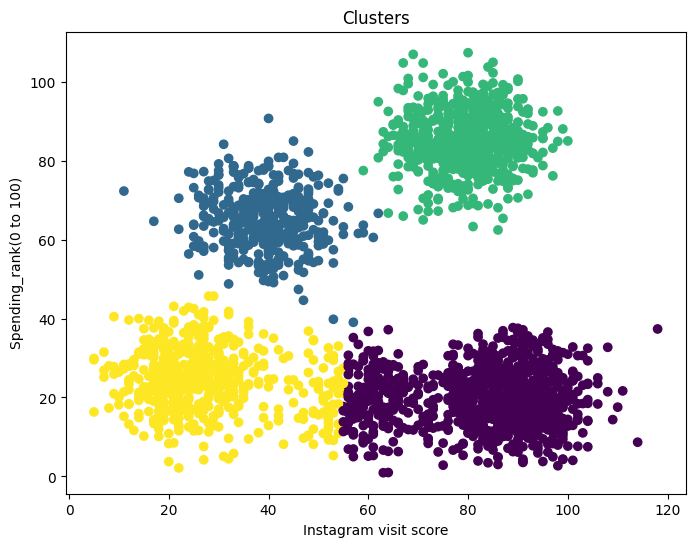

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Instagram visit score'],
    df['Spending_rank(0 to 100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel('Instagram visit score')
plt.ylabel('Spending_rank(0 to 100)')
plt.title('Clusters')
plt.show()

In [53]:
kmeans.cluster_centers_

array([[ 0.74958532, -0.79908419],
       [-0.90211775,  0.77502236],
       [ 0.61304814,  1.46685066],
       [-1.35568221, -0.64478164]])

In [54]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Instagram visit score', 'Spending_rank(0 to 100)']
)

centroids

,Instagram visit score,Spending_rank(0 to 100)
0,0.749585,-0.799084
1,-0.902118,0.775022
2,0.613048,1.466851
3,-1.355682,-0.644782


In [55]:
df['Cluster'].value_counts().sort_index()

Cluster
0    1027
1     400
2     600
3     573
Name: count, dtype: int64

In [57]:
df['Cluster'] = kmeans.labels_

cluster_mean = df.groupby('Cluster')[['Instagram visit score', 'Spending_rank(0 to 100)']].mean()

cluster_mean

,Instagram visit score,Spending_rank(0 to 100)
Cluster,,
0,83.243427,19.872486
1,39.350000,65.132485
2,79.615000,85.024498
3,27.296684,24.309119


In [ ]:
df.head()

,Instagram visit score,Spending_rank(0 to 100),Cluster
0,63,24.050708,0
1,61,25.223290,0
2,104,18.528245,0
3,82,86.890232,2
4,14,31.492397,3


In [58]:
df.groupby('Cluster')[['Instagram visit score', 'Spending_rank(0 to 100)']].mean()

,Instagram visit score,Spending_rank(0 to 100)
Cluster,,
0,83.243427,19.872486
1,39.350000,65.132485
2,79.615000,85.024498
3,27.296684,24.309119


In [59]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_original

array([[83.24342746, 19.87248561],
       [39.35      , 65.13248481],
       [79.615     , 85.0244978 ],
       [27.29668412, 24.30911866]])

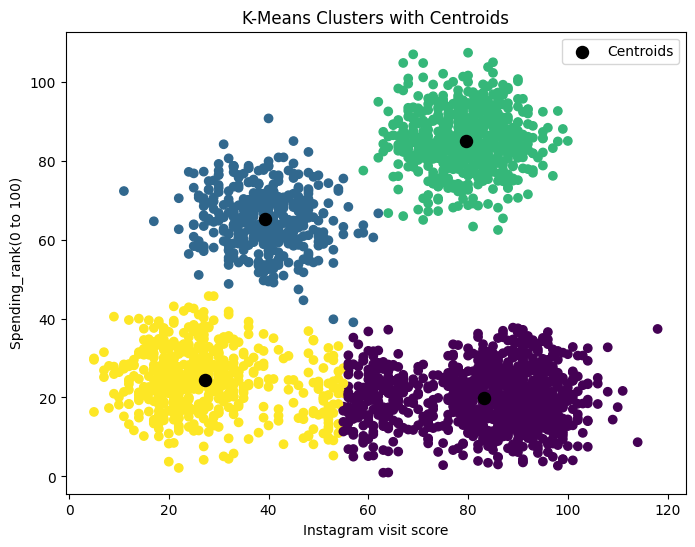

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Instagram visit score'],
    df['Spending_rank(0 to 100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker='o',
    s=75,
    color='black',
    label='Centroids'
)

plt.xlabel('Instagram visit score')
plt.ylabel('Spending_rank(0 to 100)')
plt.title('K-Means Clusters with Centroids')
plt.legend()
plt.show()

In [61]:
cluster_summary = df.groupby('Cluster').agg(
    avg_distance=('Instagram visit score', 'mean'),
    avg_speed=('Spending_rank(0 to 100)', 'mean'),
    customer_count=('Cluster', 'count')
)

cluster_summary

,avg_distance,avg_speed,customer_count
Cluster,,,
0,83.243427,19.872486,1027
1,39.350000,65.132485,400
2,79.615000,85.024498,600
3,27.296684,24.309119,573
